## Modelado con K-Means

In [118]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from matplotlib import cm
import plotly.express as px
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
from sklearn.mixture import GaussianMixture


In [119]:
df_dqi =pd.read_csv('./Data/Processed/df_dqi_final.csv', sep=';')
df_dqi.head()

,folio_integrante,macronutrients_dqi,fatty_acids_dqi,balance_dqi,empty_calories_dqi,total_fat_dqi,saturated_fat_dqi,cholesterol_dqi,sodium_dqi,moderation_dqi,dqi_food_groups,dqi_protein_sources,...,grupo,resultado_general_entrevista,region_Centro,region_Centro Norte,region_Frontera,region_Pacifico-Norte,region_Pacífico Sur,region_Pacífico-Centro,region_Península,sexo_Mujer,estrato_Rural ( <2500 Hab ),"estrato_Urbano ( 2500-99,999 Hab)"
0,2022_01001001_01,0,0,0,0,0,0,6,6,12,12,5,...,Adolescentes y Adultos,1,False,True,False,False,False,False,False,True,False,False
1,2022_01001028_04,0,0,0,3,0,0,0,6,9,12,5,...,Adolescentes y Adultos,1,False,True,False,False,False,False,False,True,False,False
2,2022_01001042_01,0,0,0,3,0,0,0,6,9,15,5,...,Adolescentes y Adultos,1,False,True,False,False,False,False,False,True,False,False
3,2022_01001075_02,0,0,0,0,0,0,0,6,6,9,5,...,Adolescentes y Adultos,1,False,True,False,False,False,False,False,True,False,False
4,2022_01001081_02,0,0,0,0,0,0,0,6,6,15,5,...,Adolescentes y Adultos,1,False,True,False,False,False,False,False,True,False,False


In [120]:
print(df_dqi.shape, df_dqi.columns)

(638, 37) Index(['folio_integrante', 'macronutrients_dqi', 'fatty_acids_dqi',
       'balance_dqi', 'empty_calories_dqi', 'total_fat_dqi',
       'saturated_fat_dqi', 'cholesterol_dqi', 'sodium_dqi', 'moderation_dqi',
       'dqi_food_groups', 'dqi_protein_sources', 'variety_dqi',
       'dqi_adequacy_fruits', 'dqi_adequacy_vegetables', 'dqi_adequacy_grains',
       'dqi_adequacy_fiber', 'dqi_adequacy_protein', 'dqi_adequacy_calcium',
       'dqi_adequacy_iron', 'dqi_adequacy_vitamin_c', 'dqi_adecuacy',
       'dqi_total', 'edad', 'ponderador', 'grupo',
       'resultado_general_entrevista', 'region_Centro', 'region_Centro Norte',
       'region_Frontera', 'region_Pacifico-Norte', 'region_Pacífico Sur',
       'region_Pacífico-Centro', 'region_Península', 'sexo_Mujer',
       'estrato_Rural  ( <2500 Hab )', 'estrato_Urbano ( 2500-99,999 Hab)'],
      dtype='object')


In [121]:
# mostrar de manera vertical
pd.set_option('display.max_columns', 25)

df_dqi.describe()

,macronutrients_dqi,fatty_acids_dqi,balance_dqi,empty_calories_dqi,total_fat_dqi,saturated_fat_dqi,cholesterol_dqi,sodium_dqi,moderation_dqi,dqi_food_groups,dqi_protein_sources,variety_dqi,dqi_adequacy_fruits,dqi_adequacy_vegetables,dqi_adequacy_grains,dqi_adequacy_fiber,dqi_adequacy_protein,dqi_adequacy_calcium,dqi_adequacy_iron,dqi_adequacy_vitamin_c,dqi_adecuacy,dqi_total,edad,ponderador,resultado_general_entrevista
count,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,6.380000e+02,638.0
mean,0.796238,0.112853,0.909091,1.147335,1.034483,0.893417,4.123824,5.943574,13.142633,9.987461,3.515674,13.503135,2.564263,3.001567,0.699060,3.186520,4.805643,3.172414,2.952978,3.873041,24.255486,51.810345,39.985893,1.115890e+05,1.0
std,1.574677,0.513361,1.616597,1.977166,1.723073,1.678543,2.525604,0.472092,5.060392,4.200602,1.770748,5.539567,1.986163,1.892312,1.052931,1.633059,0.592867,1.476681,1.712723,1.631093,8.509977,12.880324,13.303537,1.340553e+05,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,2.000000,19.000000,18.000000,7.032174e+03,1.0
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,6.000000,9.000000,6.000000,3.000000,9.000000,1.000000,1.000000,0.000000,2.000000,5.000000,2.000000,1.000000,3.000000,18.000000,42.000000,28.000000,3.160034e+04,1.0
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,6.000000,12.000000,12.000000,5.000000,14.500000,2.000000,3.000000,0.000000,3.000000,5.000000,3.000000,3.000000,5.000000,25.000000,53.000000,40.000000,6.486087e+04,1.0
75%,0.000000,0.000000,2.000000,3.000000,3.000000,0.000000,6.000000,6.000000,15.000000,12.000000,5.000000,17.000000,5.000000,5.000000,1.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,61.000000,51.000000,1.352364e+05,1.0
max,6.000000,4.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,30.000000,15.000000,5.000000,20.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,40.000000,84.000000,64.000000,1.145273e+06,1.0


Como podemos observar en el resultado anterior, tenemos 37 columnas y solo 638 registros, por lo cual será difícil para los modelos encontrar clusters en un espacio con tantas dimensiones y pocos registros. Es por esto que primero aplicaremos PCA para reducir la dimensionalidad de nuestro data set, tratando de mantener la mayor cantidad de variabilidad poisible.

In [122]:

## Eliminar columnas que no se utilizarán en el proceso de clustering
df_clustering_pca = df_dqi.copy()
df_clustering_pca.drop(columns=['folio_integrante','edad', 'ponderador', 'grupo','resultado_general_entrevista'], inplace=True)


Aplicamos PCA

In [123]:
pipeline = Pipeline([
    ('scaler', MinMaxScaler()),       
    ('pca', PCA(n_components=0.9))   
])

# 2. Ajustar el pipeline a los datos
df_clustering_pca = pipeline.fit_transform(df_clustering_pca)

# Ver resultados
pca_model = pipeline.named_steps['pca']
print(f"Cantidad de componentes seleccionadas: {pca_model.n_components_}")
print(f"Porcentaje de varianza explicada: {pca_model.explained_variance_ratio_.sum() * 100:.2f}%")

df_clustering_pca = pd.DataFrame(df_clustering_pca, columns=[f"PC{i+1}" for i in range(pca_model.n_components_)])
df_clustering_pca.head()


Cantidad de componentes seleccionadas: 15
Porcentaje de varianza explicada: 90.66%


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15
0,-0.560050,0.458432,-0.348514,-0.627531,0.477133,0.358532,-0.005317,-0.080983,-0.482715,-0.299696,-0.145780,0.120180,0.111291,-0.014983,0.016565
1,-0.933954,0.125753,-0.255348,-0.705600,0.575939,0.347749,0.231043,-0.160024,0.061143,0.367161,0.196650,0.363558,-0.042829,-0.018390,-0.050924
2,-0.984813,0.176949,-0.260545,-0.725718,0.567069,0.293605,0.175819,-0.221343,-0.046442,0.337095,0.380172,0.201551,0.043505,0.007387,-0.041734
3,-0.012718,-0.430470,-0.148054,-0.736026,0.776365,0.286743,0.130320,-0.351362,0.478603,0.075125,-0.214561,0.573191,-0.104200,0.047117,0.096568
4,-1.320348,0.056527,-0.203088,-0.607941,0.618769,0.298727,0.014224,-0.271601,0.034773,-0.104282,0.210458,0.324665,-0.177543,-0.066637,0.032824


Según los resultados anteriores, seleccionando 18 componentes principales se logra explicar el 95% de la varianza de los datos. Por lo cual continuaremos con este dataset más reducido para realizar el clustering.

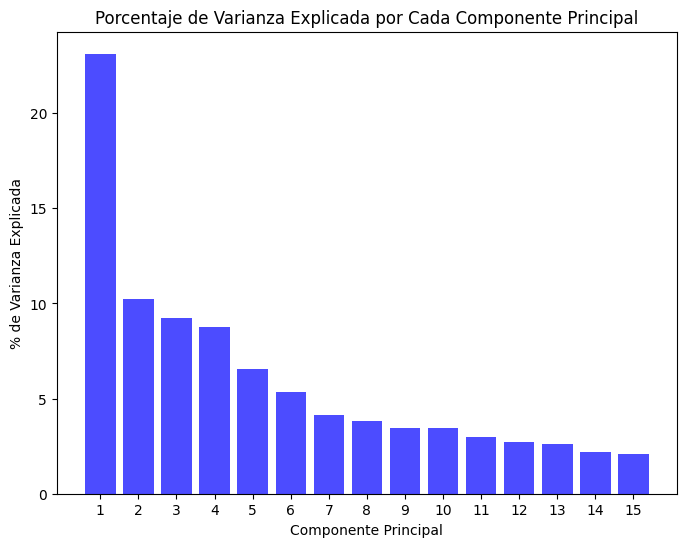

In [124]:
pca_model = pipeline.named_steps['pca']

# 1. Graficar el porcentaje de varianza explicada por cada componente
plt.figure(figsize=(8, 6))
plt.bar(np.arange(1, pca_model.n_components_ + 1), pca_model.explained_variance_ratio_ * 100, alpha=0.7, color='b')

# Etiquetas y título
plt.title('Porcentaje de Varianza Explicada por Cada Componente Principal')
plt.xlabel('Componente Principal')
plt.ylabel('% de Varianza Explicada')
plt.xticks(np.arange(1, pca_model.n_components_ + 1))  
plt.show()

Se crean funciones para el entrenamiento y la evaluación del modelo.

In [125]:


def kmeans(X, clusters,sample_weight=None):
    silhouette_scores = []

    for cluster in clusters:
        # a
        kmeans = KMeans(n_clusters=cluster, random_state=42)
        labels = kmeans.fit_predict(X,sample_weight=sample_weight)  # Ajustar el modelo y predecir los clusters
        score = silhouette_score(X, labels)
        silhouette_scores.append(score)
        plot_silhouette(X, labels, cluster)

    return silhouette_scores

def plot_silhouette(X, labels, cluster):
    silhouette_vals = silhouette_samples(X, labels)
    y_lower, y_upper = 0, 0
    n_clusters = np.unique(labels).shape[0]
    plt.figure(figsize=(7, 5))

    for i in range(n_clusters):
        ith_cluster_silhouette_values = silhouette_vals[labels == i]
        ith_cluster_silhouette_values.sort()
        y_upper += len(ith_cluster_silhouette_values)
        color = cm.nipy_spectral(float(i) / n_clusters)
        plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)
        y_lower = y_upper

    plt.axvline(x=np.mean(silhouette_vals), color="red", linestyle="--")
    plt.title(f'Grafica de silueta para el cluster {cluster}')
    plt.xlabel('Coeficiente de la silueta')
    plt.ylabel('Cluster')
    plt.tight_layout()
    plt.show()

def plot_silhouette_vs_cluster(clusters, silhouette_scores):
    plt.figure(figsize=(8, 6))
    plt.plot(clusters, silhouette_scores, marker='o', linestyle='-', color='b')
    plt.title('Coeficiente de la silueta por clusters')
    plt.xlabel('Clusters')
    plt.ylabel('Coeficiente de la silueta')
    plt.grid(True)
    plt.show()

def plot_centroid_spider_plotly(centroids, k):
    # Crear un DataFrame con los centroides
    num_features = centroids.shape[1]
    feature_labels = [f'Feature {i + 1}' for i in range(num_features)]
    
    # Preparar los datos para Plotly
    data = []
    for i in range(k):
        values = centroids[i].tolist() + [centroids[i][0]]  # Cerrar el círculo
        data.append(values)
    
    # Crear un DataFrame
    df = pd.DataFrame(data, columns=feature_labels + ['Feature 1'])
    df['Cluster'] = [f'Cluster {i + 1}' for i in range(k)]
    df = pd.melt(df, id_vars='Cluster', value_vars=feature_labels, var_name='Feature', value_name='Value')

    # Gráfico de araña (radar)
    fig = px.line_polar(df, r='Value', theta='Feature', color='Cluster', line_close=True,
                         title=f'Spider Plot for {k} Clusters')
    
    fig.update_traces(fill='toself', opacity=0.25)  # Rellenar el área
    fig.show()



A continuación se realizará el proceso de clustering utilizando el método de KMeans. Para ello, se utilizará la función kmeans que recibe como parámetros los datosdespués de pasar por PCA y el rango de clusters a evaluar. En este caso, se evaluarán desde 2 hasta 10 clusters.

c:\Users\chris\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



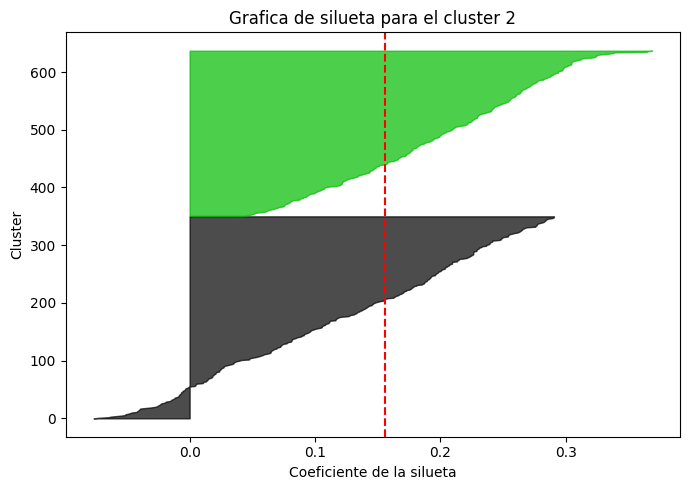

c:\Users\chris\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



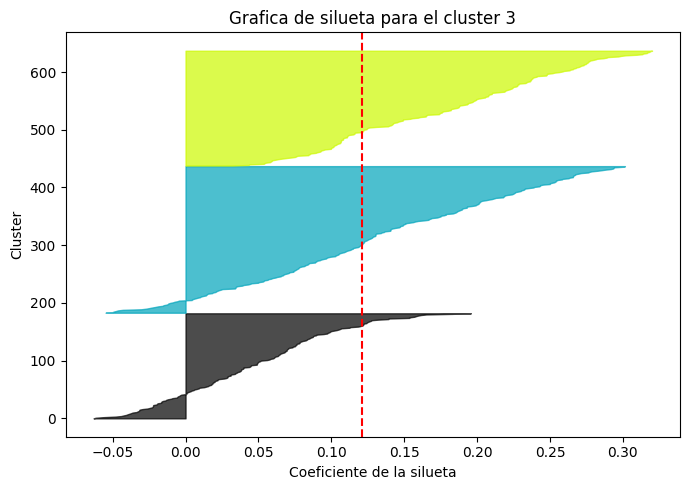

c:\Users\chris\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



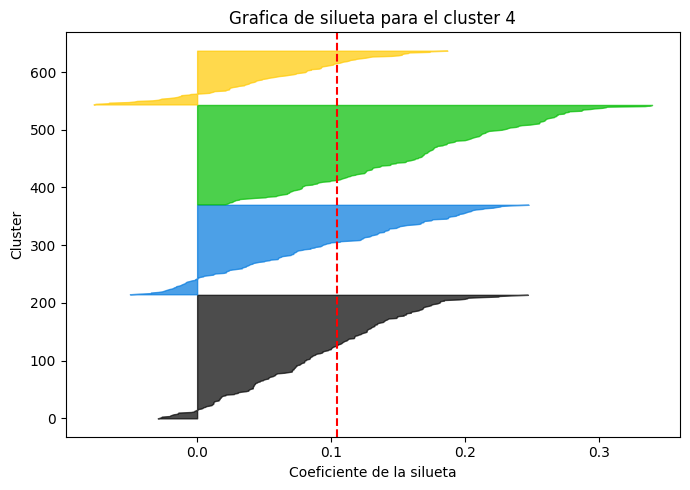

c:\Users\chris\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



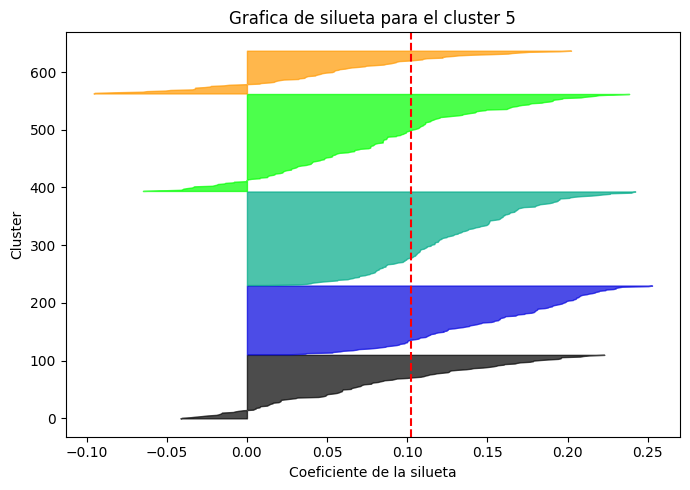

c:\Users\chris\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



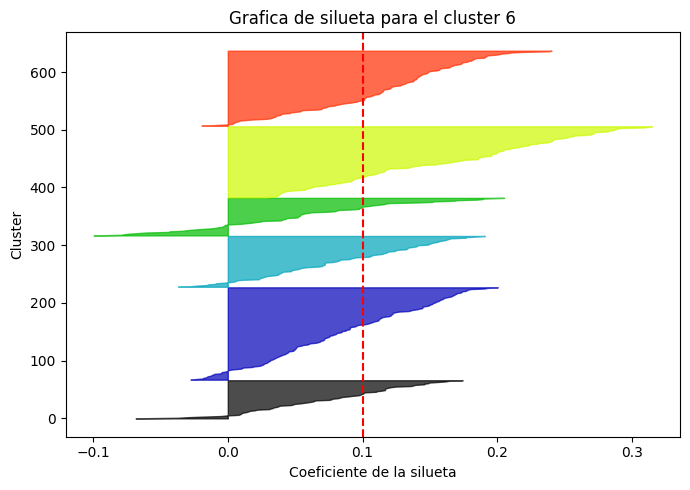

c:\Users\chris\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



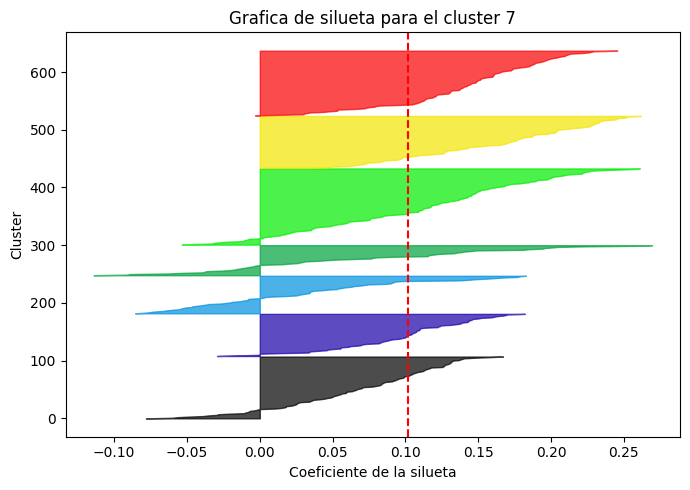

c:\Users\chris\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



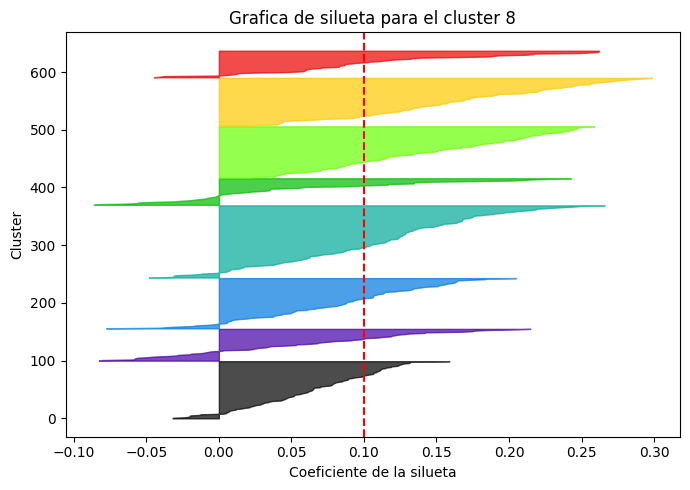

c:\Users\chris\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



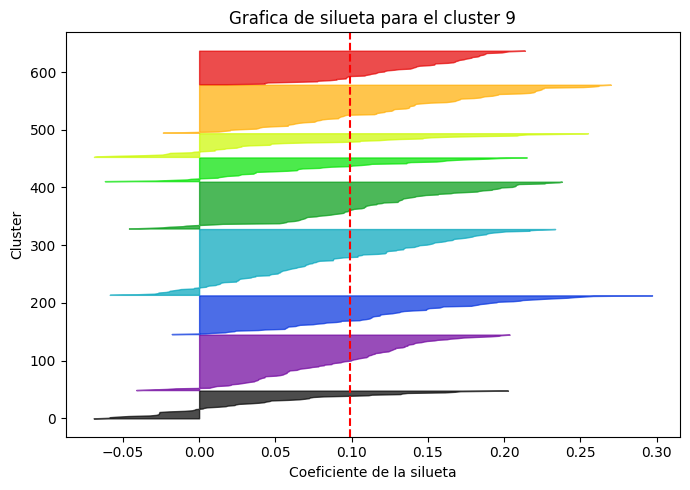

cluster = 2, Puntaje de Silueta = 0.15569085989468656
cluster = 3, Puntaje de Silueta = 0.12137503731981487
cluster = 4, Puntaje de Silueta = 0.1042405186362221
cluster = 5, Puntaje de Silueta = 0.10233674453189168
cluster = 6, Puntaje de Silueta = 0.10007529081393113
cluster = 7, Puntaje de Silueta = 0.10154480160037774
cluster = 8, Puntaje de Silueta = 0.09972892833551786
cluster = 9, Puntaje de Silueta = 0.09917084875338904


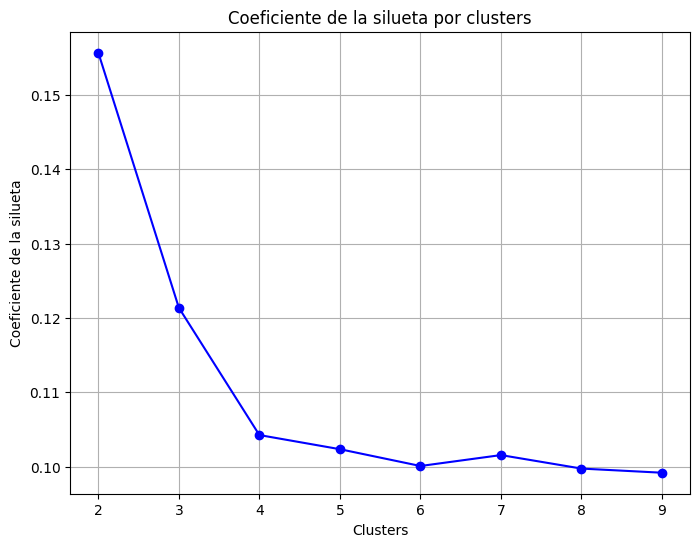

In [126]:

# Especificamos los números de clusters a evaluar
clusters = range(2, 10)  
# Ejecutamos KMeans y graficamos los resultados
silhouette_scores = kmeans(df_clustering_pca, clusters,sample_weight=df_dqi['ponderador'])
for cluster, score in zip(clusters, silhouette_scores):
    print(f'cluster = {cluster}, Puntaje de Silueta = {score}')
# Graficamos el coeficiente de silueta para cada número de clusters
plot_silhouette_vs_cluster(clusters, silhouette_scores)


In [129]:
n_clusters = 2

kmeans = KMeans(n_clusters=n_clusters, random_state=42, max_iter=10000)
labels = kmeans.fit_predict(df_clustering_pca,sample_weight=df_dqi['ponderador'])
# Obtener los centroides
centroids = kmeans.cluster_centers_

# Graficar los centroides en un gráfico radial
plot_centroid_spider_plotly(centroids, n_clusters)

c:\Users\chris\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

c:\Users\chris\AppData\Local\Programs\Python\Python39\lib\site-packages\plotly\express\_core.py:271: FutureWarning:

The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.

c:\Users\chris\AppData\Local\Programs\Python\Python39\lib\site-packages\plotly\express\_core.py:271: FutureWarning:

The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.



In [ ]:
df_dqi = df_dqi.assign(Cluster=labels)
df_dqi.head()

,folio_integrante,macronutrients_dqi,fatty_acids_dqi,balance_dqi,empty_calories_dqi,total_fat_dqi,saturated_fat_dqi,cholesterol_dqi,sodium_dqi,moderation_dqi,dqi_food_groups,dqi_protein_sources,...,resultado_general_entrevista,region_Centro,region_Centro Norte,region_Frontera,region_Pacifico-Norte,region_Pacífico Sur,region_Pacífico-Centro,region_Península,sexo_Mujer,estrato_Rural ( <2500 Hab ),"estrato_Urbano ( 2500-99,999 Hab)",Cluster
0,2022_01001001_01,0,0,0,0,0,0,6,6,12,12,5,...,1,False,True,False,False,False,False,False,True,False,False,1
1,2022_01001028_04,0,0,0,3,0,0,0,6,9,12,5,...,1,False,True,False,False,False,False,False,True,False,False,1
2,2022_01001042_01,0,0,0,3,0,0,0,6,9,15,5,...,1,False,True,False,False,False,False,False,True,False,False,1
3,2022_01001075_02,0,0,0,0,0,0,0,6,6,9,5,...,1,False,True,False,False,False,False,False,True,False,False,0
4,2022_01001081_02,0,0,0,0,0,0,0,6,6,15,5,...,1,False,True,False,False,False,False,False,True,False,False,1


In [131]:
## reversar one hot encoding

df_dqi['region'] = df_dqi[['region_Centro', 'region_Centro Norte', 'region_Frontera', 'region_Pacifico-Norte', 'region_Pacífico Sur', 'region_Pacífico-Centro', 'region_Península']].idxmax(axis=1)
df_dqi['estrato'] = df_dqi[['estrato_Rural  ( <2500 Hab )', 'estrato_Urbano ( 2500-99,999 Hab)']].idxmax(axis=1)
df_dqi.drop(columns=['region_Centro', 'region_Centro Norte', 'region_Frontera', 'region_Pacifico-Norte', 'region_Pacífico Sur', 'region_Pacífico-Centro', 'region_Península', 'estrato_Rural  ( <2500 Hab )', 'estrato_Urbano ( 2500-99,999 Hab)'], inplace=True)



In [132]:
# Crear una columna sexo a partir de la columna sexo_Mujer
df_dqi['sexo'] = df_dqi['sexo_Mujer'].map({True: 'Mujer', False: 'Hombre'})
df_dqi.drop(columns=['sexo_Mujer'], inplace=True)

In [133]:
df_dqi['region'] = df_dqi['region'].apply(lambda x: x.split('_')[1])
df_dqi['estrato'] = df_dqi['estrato'].apply(lambda x: x.split('_')[1])
df_dqi.head()

,folio_integrante,macronutrients_dqi,fatty_acids_dqi,balance_dqi,empty_calories_dqi,total_fat_dqi,saturated_fat_dqi,cholesterol_dqi,sodium_dqi,moderation_dqi,dqi_food_groups,dqi_protein_sources,...,dqi_adequacy_iron,dqi_adequacy_vitamin_c,dqi_adecuacy,dqi_total,edad,ponderador,grupo,resultado_general_entrevista,Cluster,region,estrato,sexo
0,2022_01001001_01,0,0,0,0,0,0,6,6,12,12,5,...,2,5,31,60,51,8717.185479,Adolescentes y Adultos,1,1,Centro Norte,Rural ( <2500 Hab ),Mujer
1,2022_01001028_04,0,0,0,3,0,0,0,6,9,12,5,...,3,5,32,58,26,51475.173556,Adolescentes y Adultos,1,1,Centro Norte,Rural ( <2500 Hab ),Mujer
2,2022_01001042_01,0,0,0,3,0,0,0,6,9,15,5,...,3,5,31,60,62,7032.174356,Adolescentes y Adultos,1,1,Centro Norte,Rural ( <2500 Hab ),Mujer
3,2022_01001075_02,0,0,0,0,0,0,0,6,6,9,5,...,2,2,20,40,33,27374.852298,Adolescentes y Adultos,1,0,Centro Norte,Rural ( <2500 Hab ),Mujer
4,2022_01001081_02,0,0,0,0,0,0,0,6,6,15,5,...,5,5,37,63,60,15823.033532,Adolescentes y Adultos,1,1,Centro Norte,Rural ( <2500 Hab ),Mujer


In [134]:
# normalizar ponderacion
df_dqi['ponderador'] = df_dqi['ponderador'].div(df_dqi['ponderador'].sum())

In [135]:
df_dqi.head()

,folio_integrante,macronutrients_dqi,fatty_acids_dqi,balance_dqi,empty_calories_dqi,total_fat_dqi,saturated_fat_dqi,cholesterol_dqi,sodium_dqi,moderation_dqi,dqi_food_groups,dqi_protein_sources,...,dqi_adequacy_iron,dqi_adequacy_vitamin_c,dqi_adecuacy,dqi_total,edad,ponderador,grupo,resultado_general_entrevista,Cluster,region,estrato,sexo
0,2022_01001001_01,0,0,0,0,0,0,6,6,12,12,5,...,2,5,31,60,51,0.000122,Adolescentes y Adultos,1,1,Centro Norte,Rural ( <2500 Hab ),Mujer
1,2022_01001028_04,0,0,0,3,0,0,0,6,9,12,5,...,3,5,32,58,26,0.000723,Adolescentes y Adultos,1,1,Centro Norte,Rural ( <2500 Hab ),Mujer
2,2022_01001042_01,0,0,0,3,0,0,0,6,9,15,5,...,3,5,31,60,62,0.000099,Adolescentes y Adultos,1,1,Centro Norte,Rural ( <2500 Hab ),Mujer
3,2022_01001075_02,0,0,0,0,0,0,0,6,6,9,5,...,2,2,20,40,33,0.000385,Adolescentes y Adultos,1,0,Centro Norte,Rural ( <2500 Hab ),Mujer
4,2022_01001081_02,0,0,0,0,0,0,0,6,6,15,5,...,5,5,37,63,60,0.000222,Adolescentes y Adultos,1,1,Centro Norte,Rural ( <2500 Hab ),Mujer


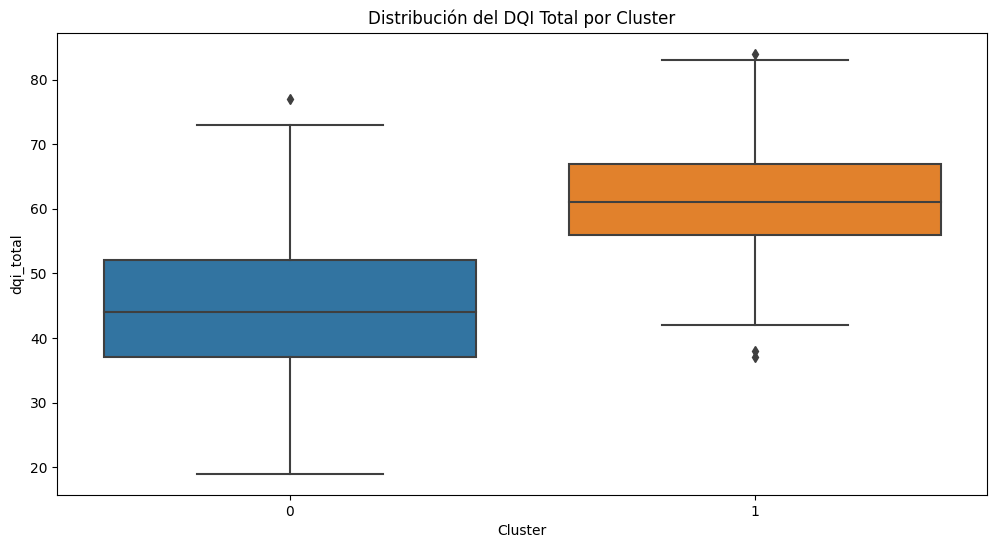

In [139]:
# generar boxplot para dos columnas

def boxplot(df, x, y, hue=None, title=None):
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=x, y=y, hue=hue, data=df)
    plt.title(title)
    plt.show()

boxplot(df_dqi, 'Cluster', 'dqi_total', title='Distribución del DQI Total por Cluster')

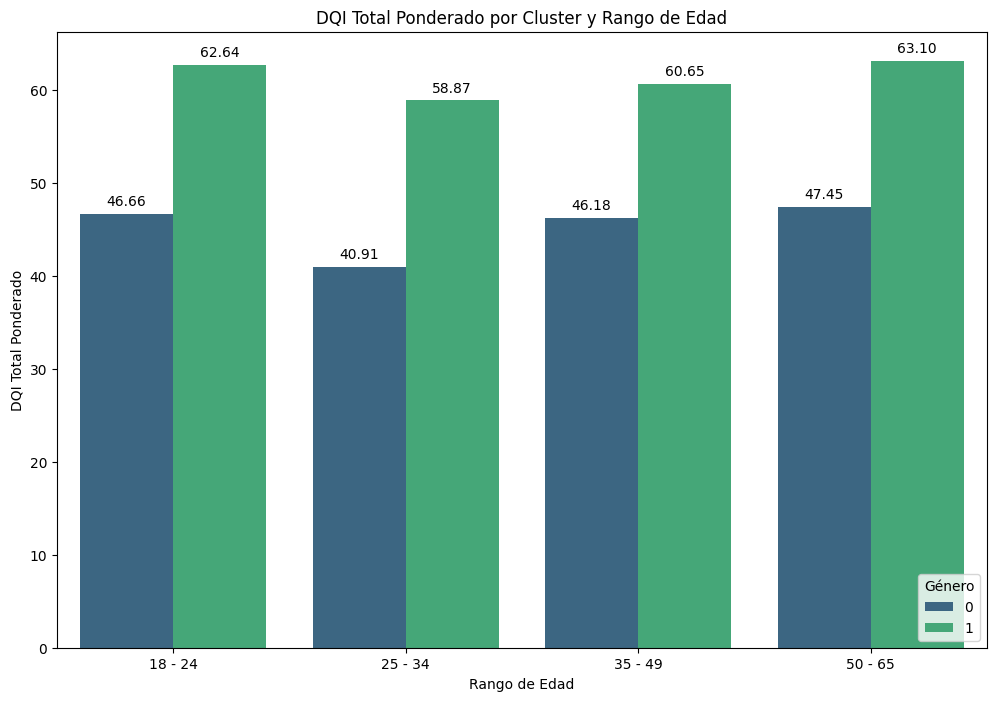

In [141]:
# Crear rangos de edad
labels = ['18 - 24', '25 - 34', '35 - 49', '50 - 65']
bins = [18, 25, 35, 50, 65]
df_dqi['edad_rango'] = pd.cut(df_dqi['edad'], bins=bins, labels=labels, right=False)

# Calcular el DQI total ponderado por género y rango de edad
weighted_dqi_by_gender_age = df_dqi.groupby(['Cluster', 'edad_rango']).apply(
    lambda x: (x['dqi_total'] * x['ponderador']).sum() / x['ponderador'].sum()
).reset_index(name='weighted_dqi_total')

# Crear el gráfico de barras
plt.figure(figsize=(12, 8))
ax = sns.barplot(data=weighted_dqi_by_gender_age, x='edad_rango', y='weighted_dqi_total', hue='Cluster', palette="viridis")
plt.title("DQI Total Ponderado por Cluster y Rango de Edad")
plt.xlabel("Rango de Edad")
plt.ylabel("DQI Total Ponderado")
plt.legend(title="Género", loc='lower right')

# Añadir etiquetas de datos
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.show()

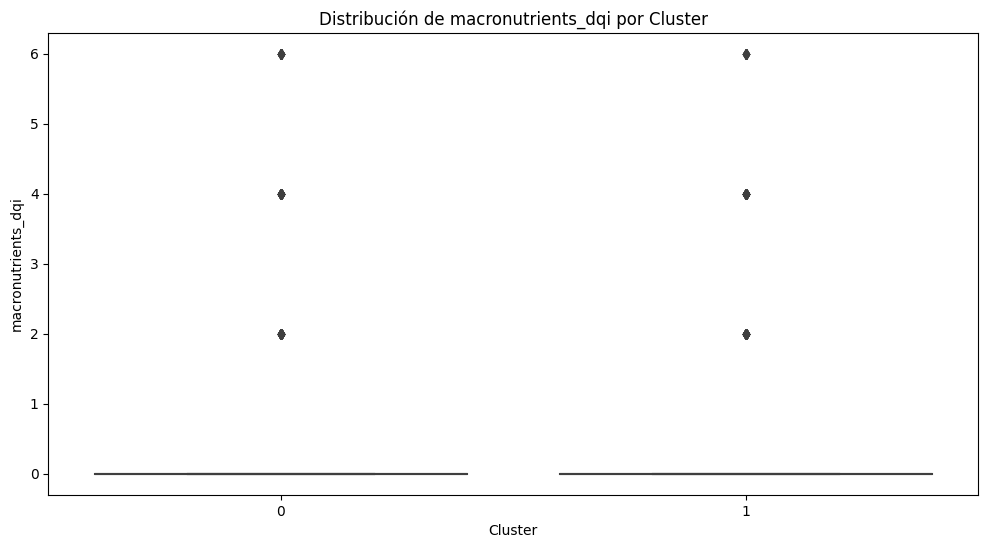

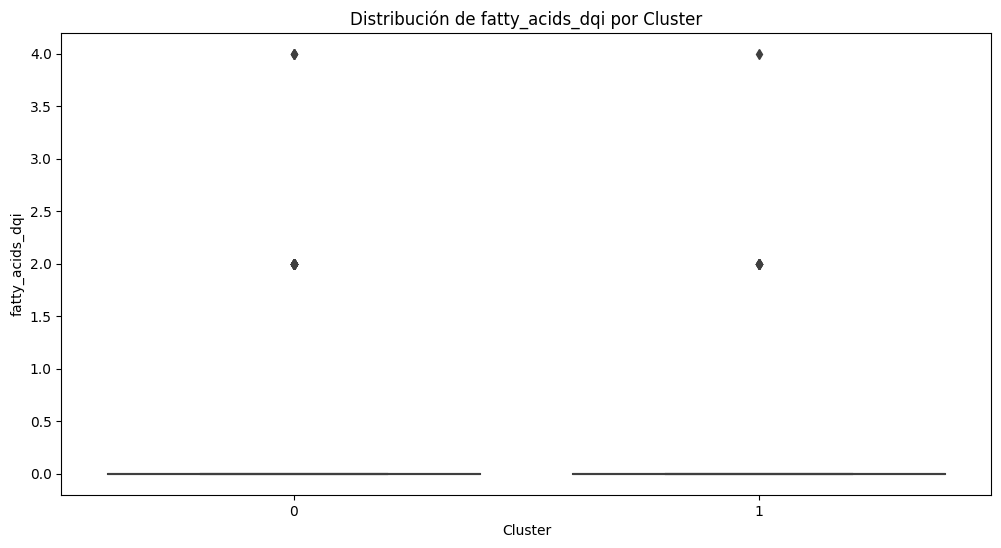

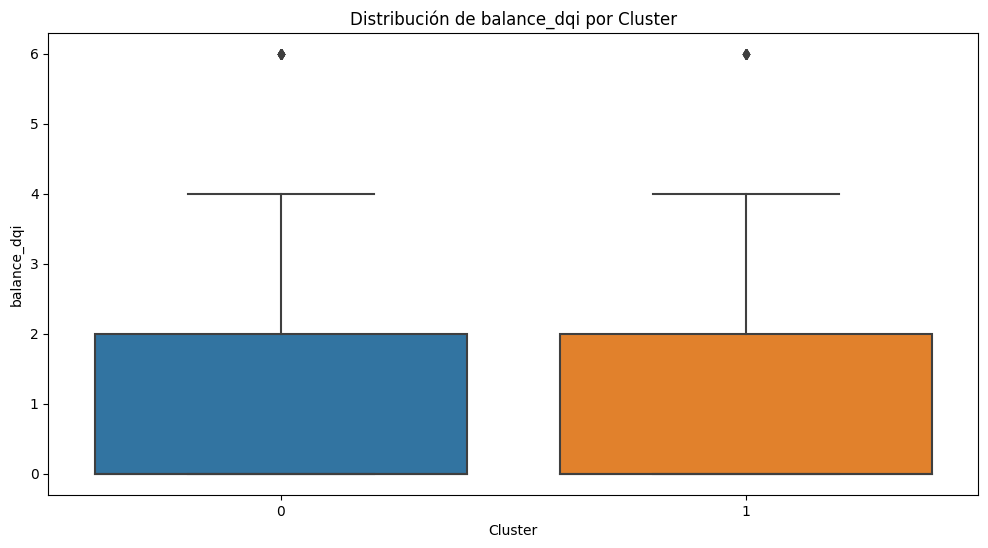

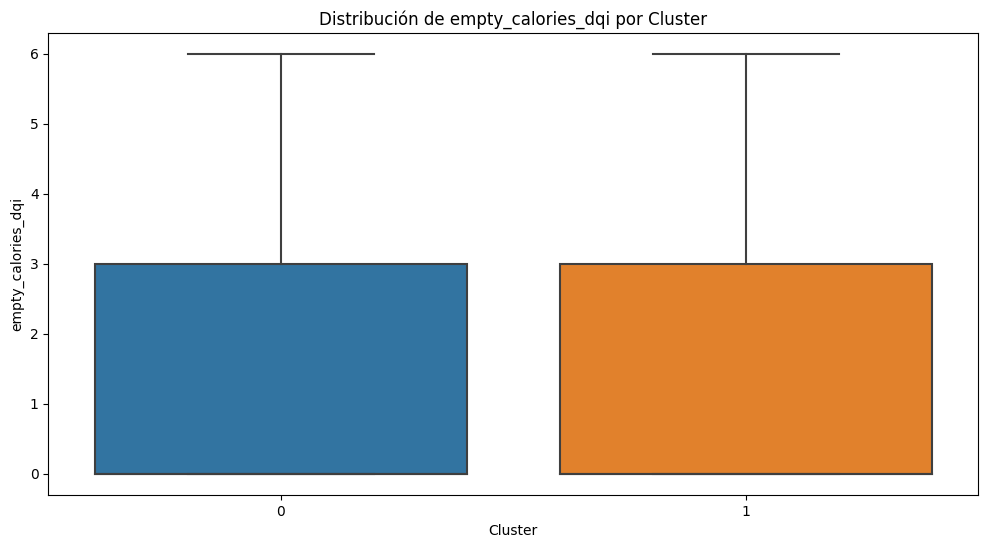

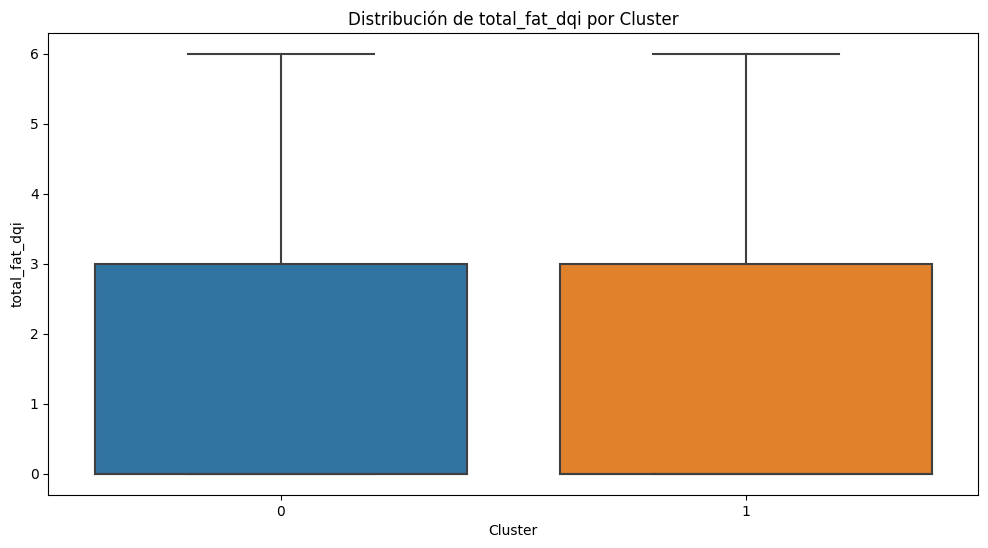

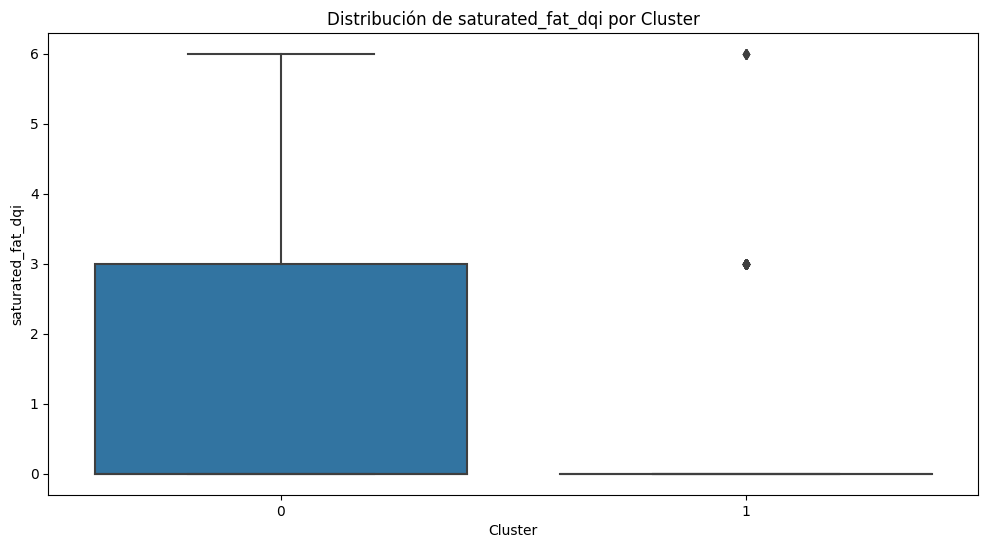

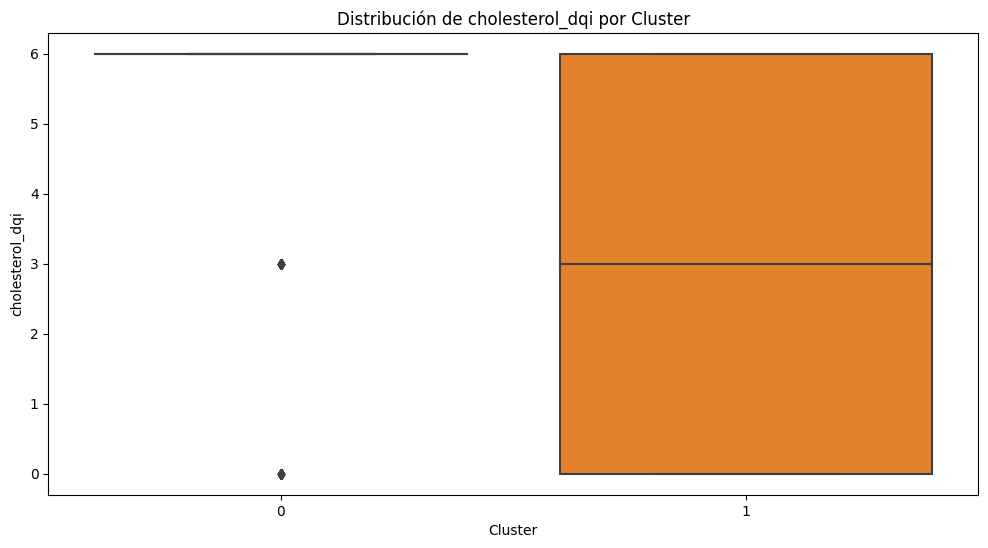

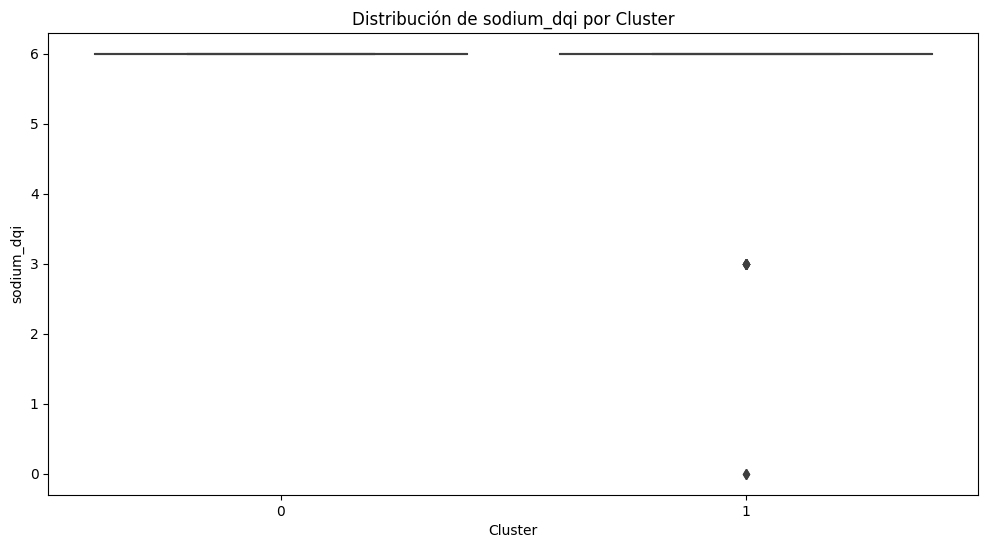

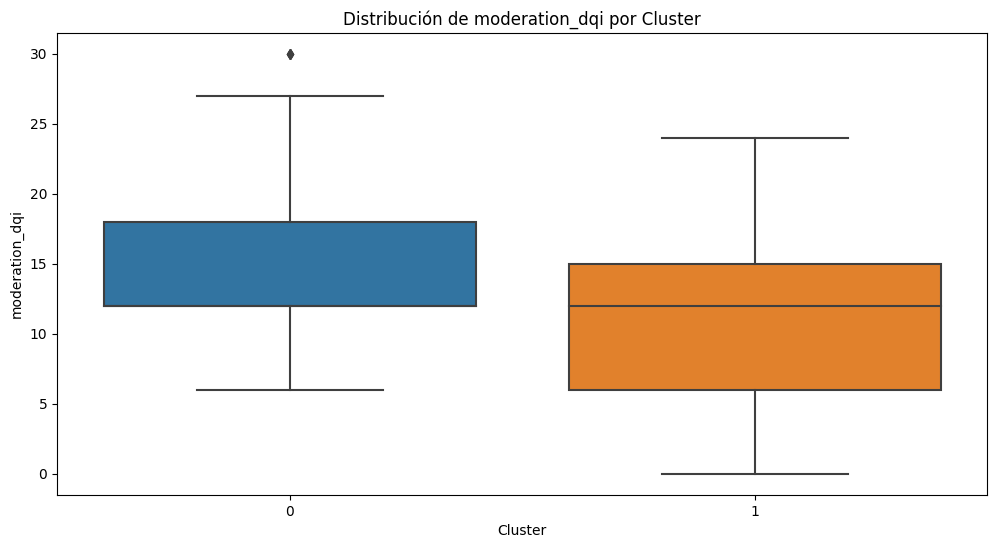

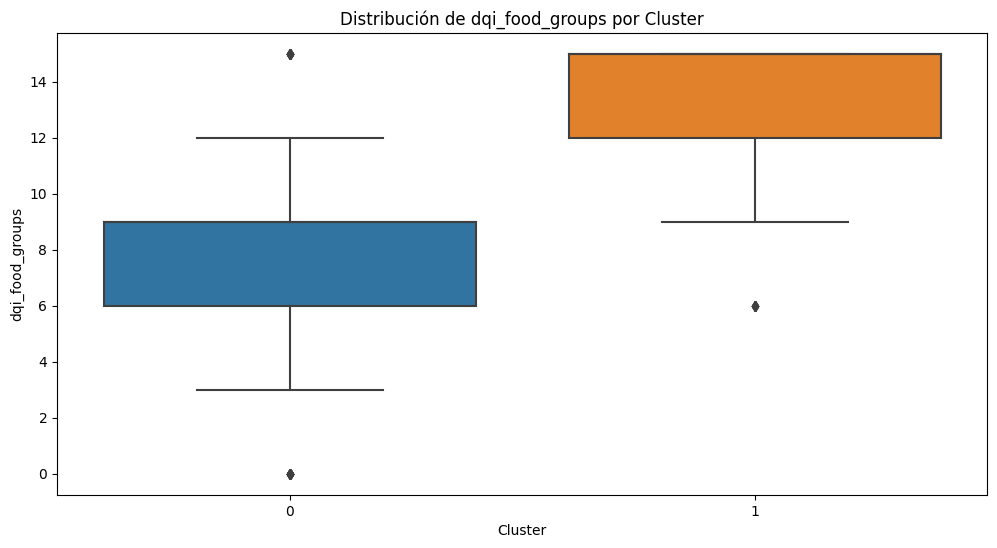

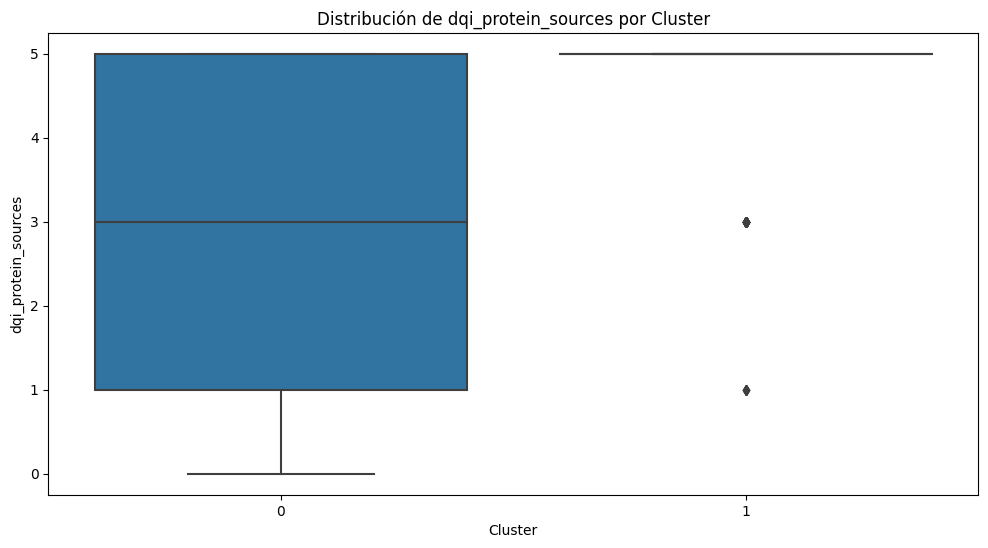

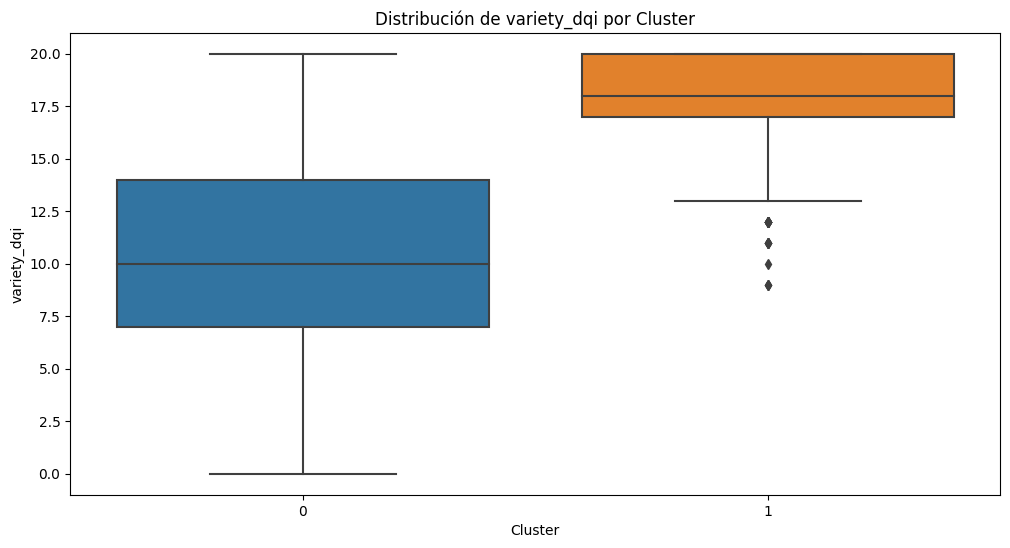

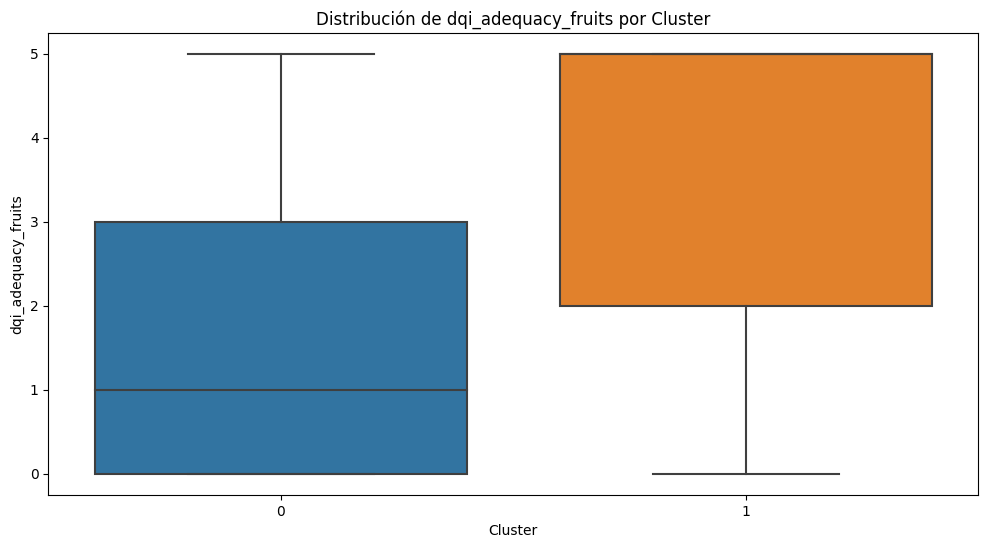

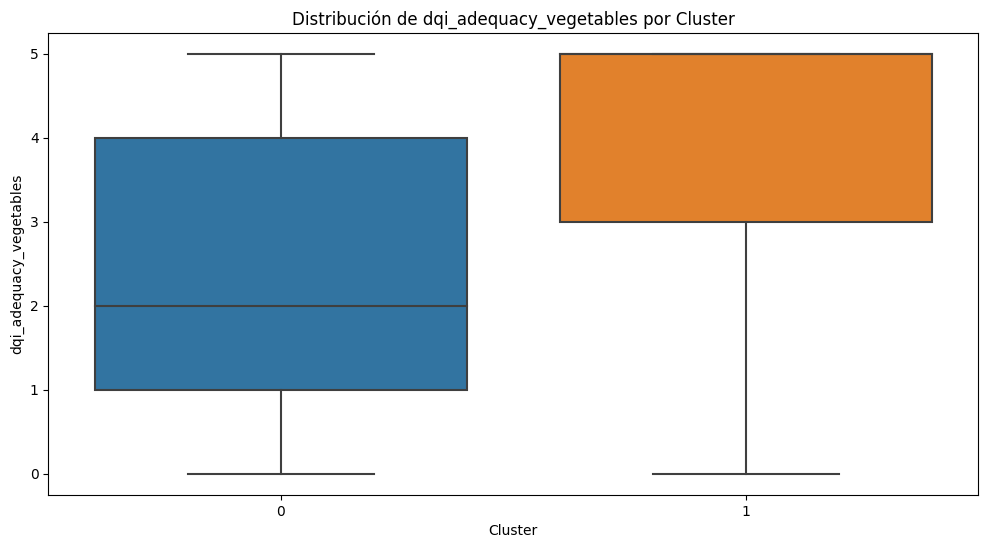

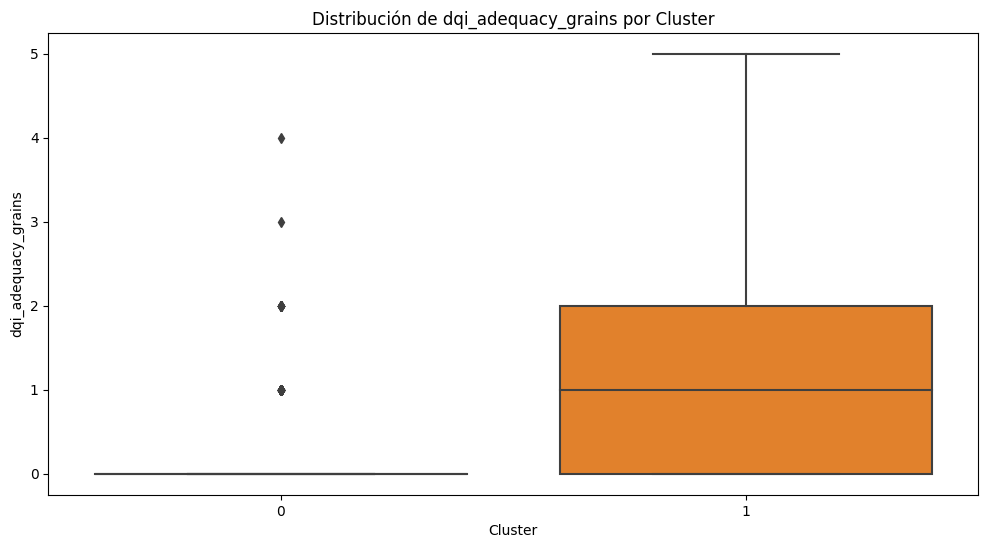

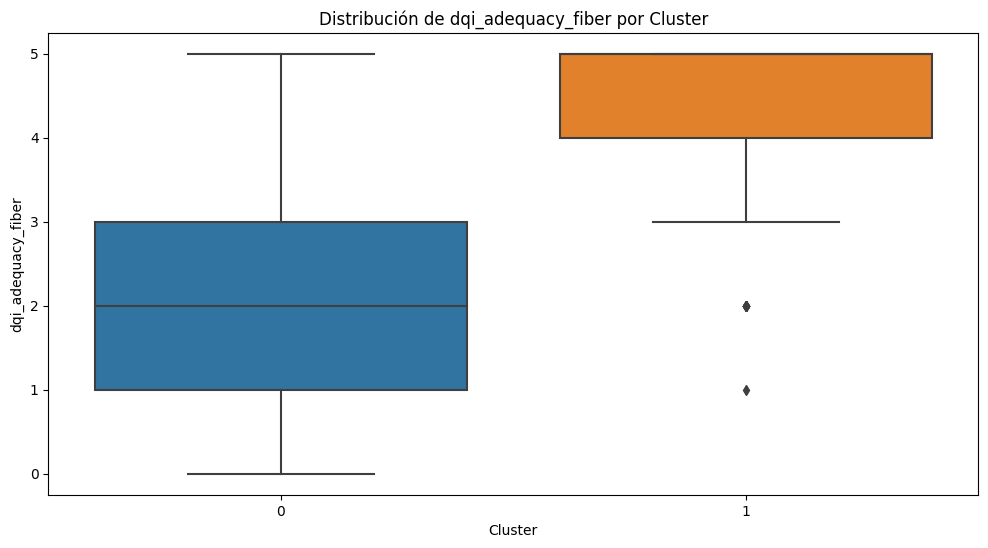

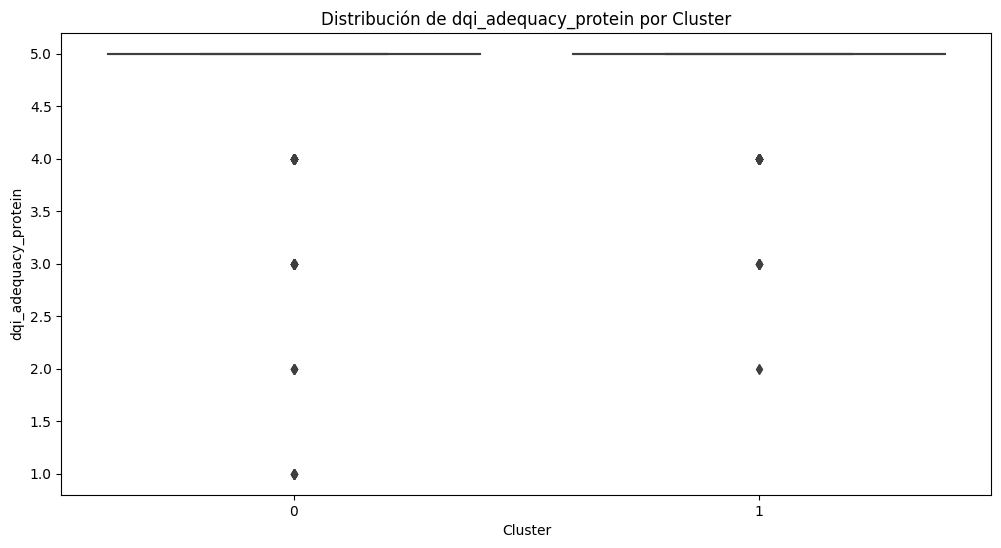

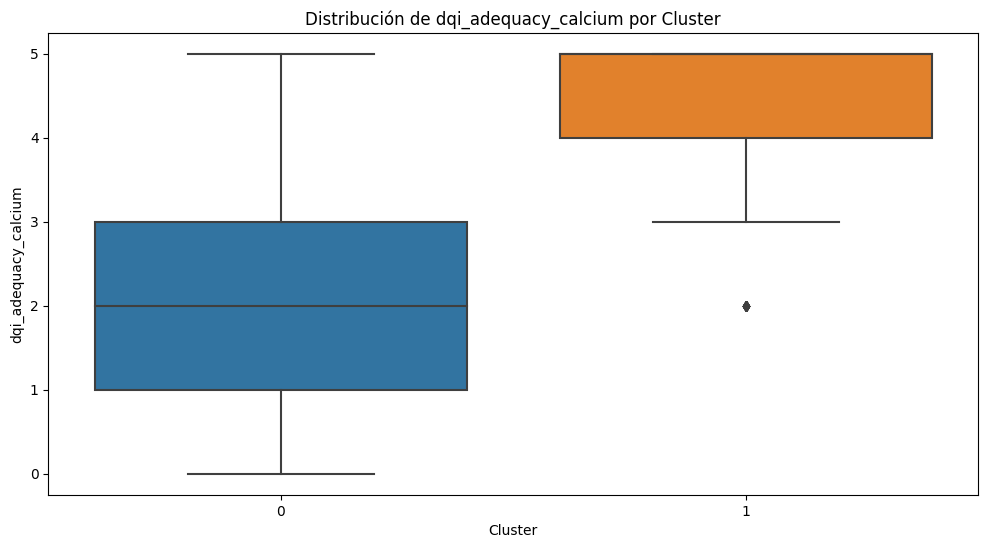

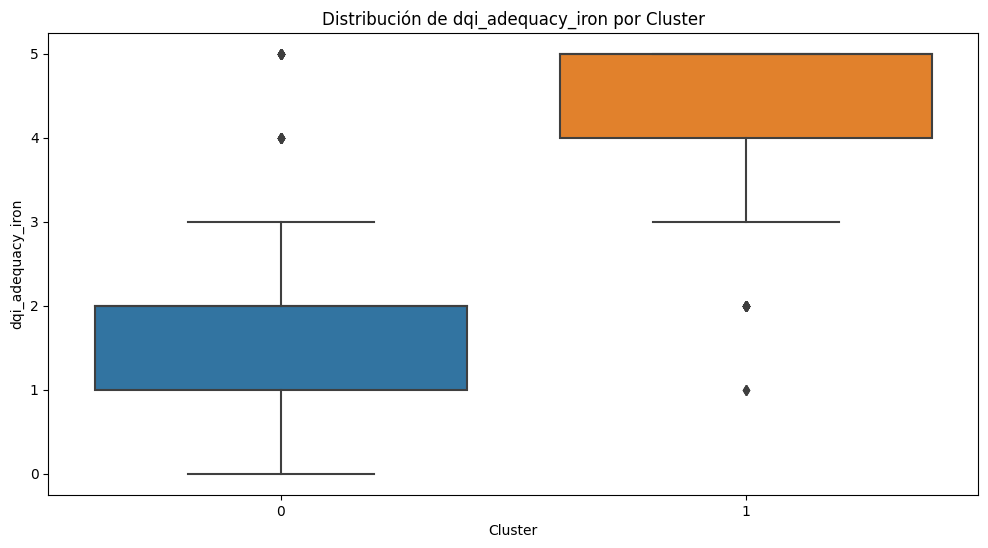

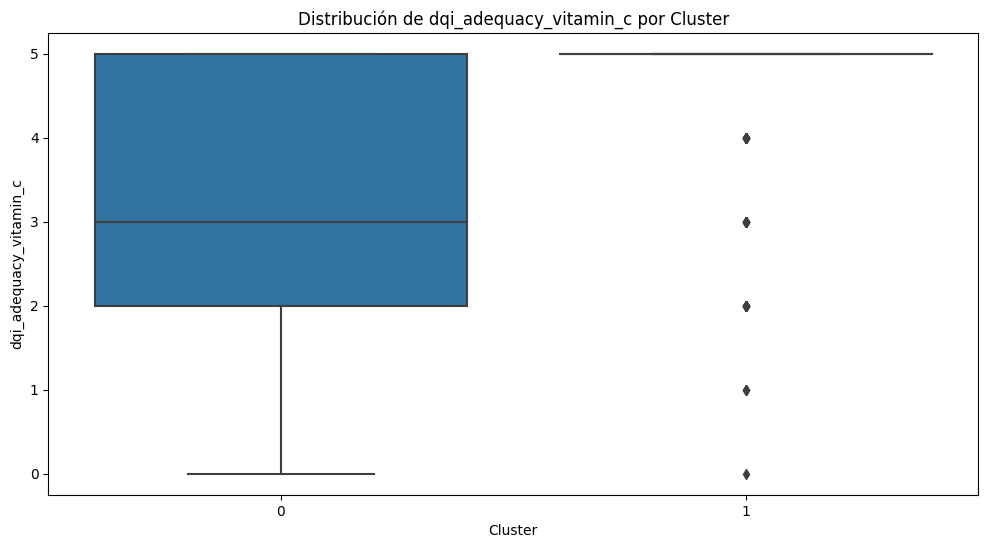

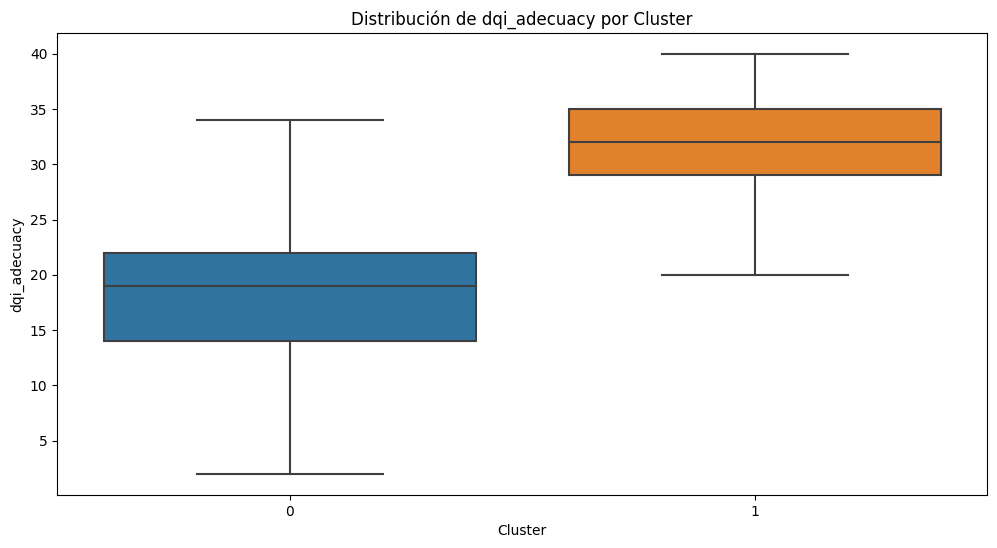

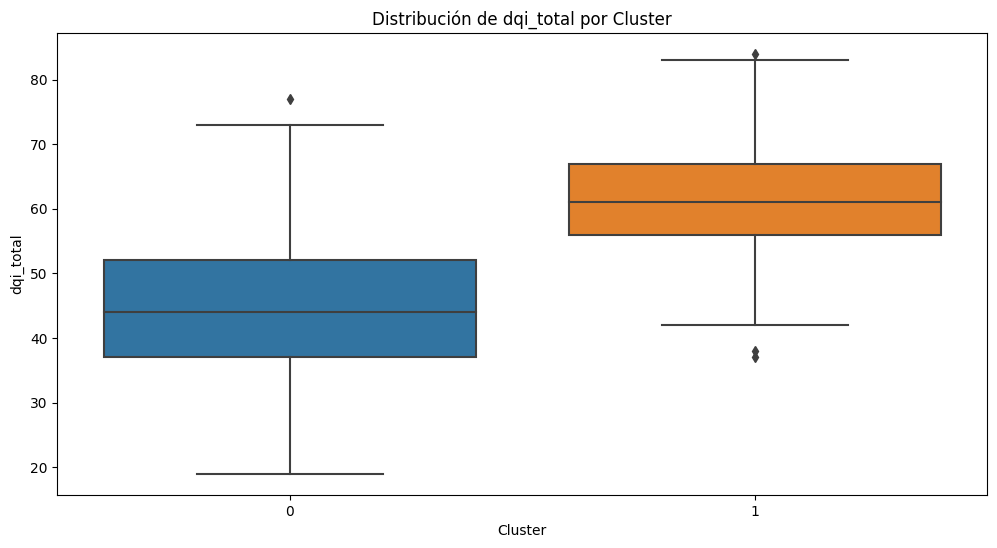

In [142]:
## Generar boxplots para todas las columnas que contengan la palabra 'dqi'
dqi_columns = df_dqi.filter(like='dqi').columns
for column in dqi_columns:
    boxplot(df_dqi, 'Cluster', column, title=f'Distribución de {column} por Cluster')
    

### Conclusiones del modelo K-Means

Como se observa en el spider plot los clusters estan mejor definidos comparado con GMM